In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

# Teleportation Protocol

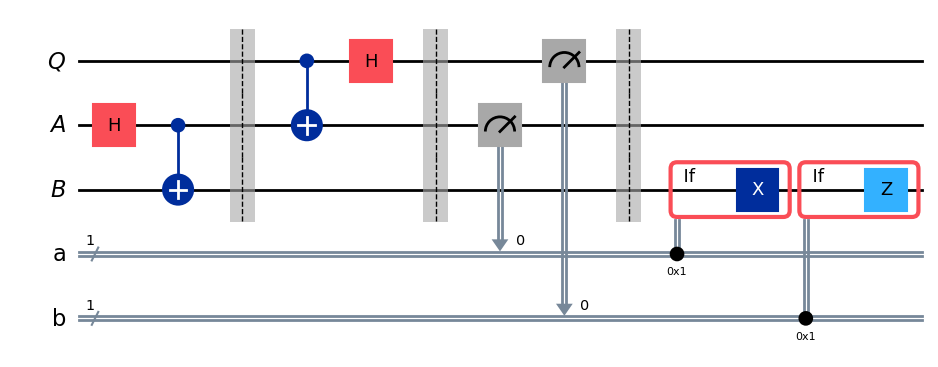

In [14]:
# quantum registers default to ket0
qubit = QuantumRegister(size=1, name='Q') # the actual qubit we want to teleport
ebit0 = QuantumRegister(1, 'A')
ebit1 = QuantumRegister(1, 'B')
a = ClassicalRegister(1, 'a')
b = ClassicalRegister(1, 'b')

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# converts A and B into |Phi+> state
# not actually part of the protocol itself, but needed to properly entangle the qubits
protocol.h(ebit0)
protocol.cx(control_qubit=ebit0, target_qubit=ebit1)
protocol.barrier() # avoids optimization across this point to maintain the structure of the circuit for demo

protocol.cx(control_qubit=qubit, target_qubit=ebit0)
protocol.h(qubit)
protocol.barrier()

protocol.measure(qubit=ebit0, cbit=a)
protocol.measure(qubit=qubit, cbit=b)
protocol.barrier()

with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

display(protocol.draw('mpl'))

# the same circuit without barriers
# protocol_no_barriers = protocol.copy() # creates a deep copy of the circuit (copies all of the registers)
# protocol_no_barriers.data = [
# instruction for instruction in protocol.data 
# if instruction.operation.name != 'barrier'
# ]

# display(protocol_no_barriers.draw('mpl'))

<IPython.core.display.Latex object>

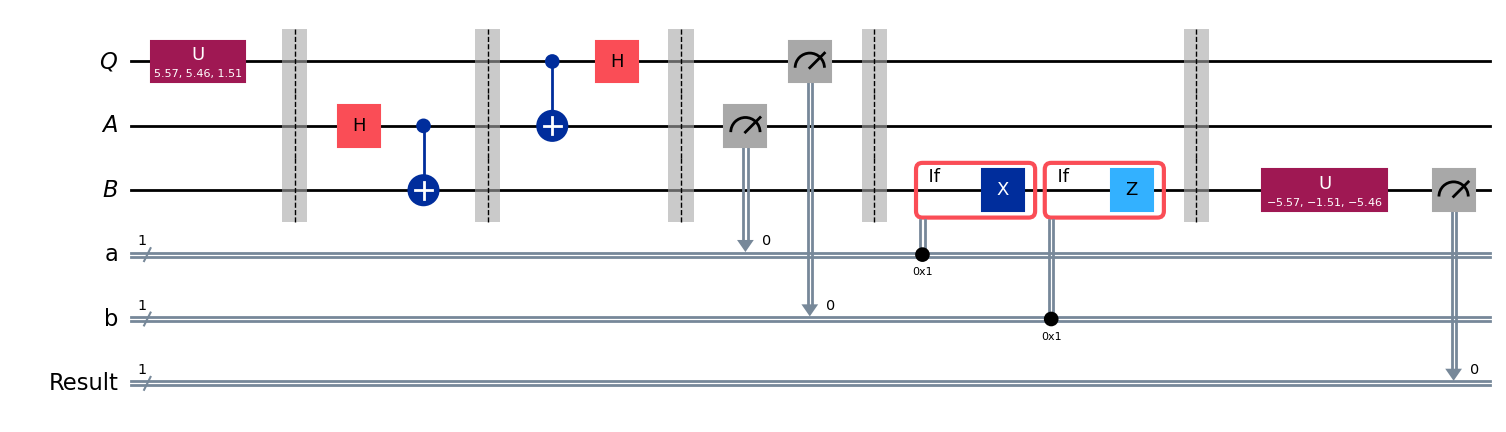

In [15]:
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi
)

display(array_to_latex(random_gate.to_matrix()))

test = QuantumCircuit(qubit, ebit0, ebit1, a, b)
test.append(instruction=random_gate, qargs=[qubit])
test.barrier()

test.compose(protocol, inplace=True)
test.barrier()

test.append(random_gate.inverse(), ebit1)
result = ClassicalRegister(1, "Result")
test.add_register(result)
test.measure(ebit1, result)

display(test.draw(output="mpl"))


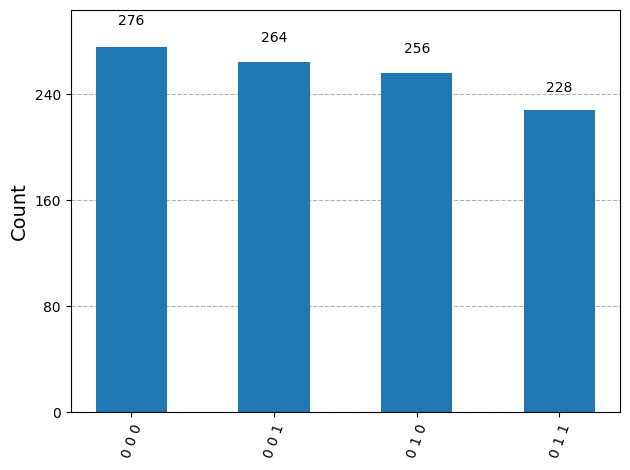

In [17]:
# notice the bottom bit is always 0, indicating that Q is in the |0> state

result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

## An Aside: Constructing the Bell State
Want to see that the preprocessing done above results in the Phi+ bell state

In [20]:
from qiskit.quantum_info import Statevector

phi_plus_entanglement_circuit = QuantumCircuit(2)

phi_plus_entanglement_circuit.h(0)
phi_plus_entanglement_circuit.cx(control_qubit=0, target_qubit=1)

state = Statevector.from_instruction(phi_plus_entanglement_circuit)
display(array_to_latex(state.data, prefix="|\\Phi^+\\rangle = "))

<IPython.core.display.Latex object>

These are the correct values for the phi+ bell state, so the circuit is correct!

# Superdense Coding

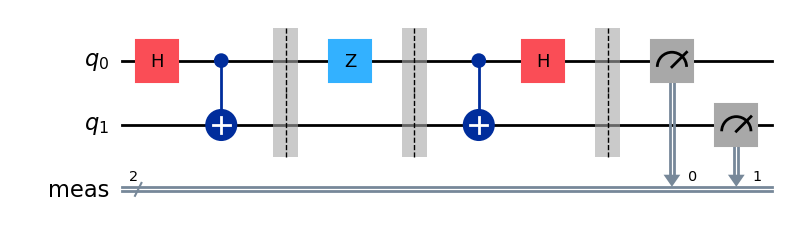

In [60]:
# note that b and a look out of order here, but trying to follow the diagram in the video
# https://www.youtube.com/watch?v=GSsElSQgMbU&list=PLOFEBzvs-VvqKKMXX4vbi4EB1uaErFMSO
# so the top (right) bit is b and the bottom (left) bit is a
b = '1'
a = '0'

# since both superdense coding and teleportation use the same bell state, we can reuse the entanglement circuit
superdense_coding = phi_plus_entanglement_circuit.copy()
superdense_coding.barrier()

if b == '1':
    superdense_coding.z(0)
if a == '1':
    superdense_coding.x(0)
superdense_coding.barrier()

superdense_coding.cx(control_qubit=0, target_qubit=1)
superdense_coding.h(0)
superdense_coding.measure_all()

display(superdense_coding.draw(output="mpl"))

Measured 01 with frequency 1024


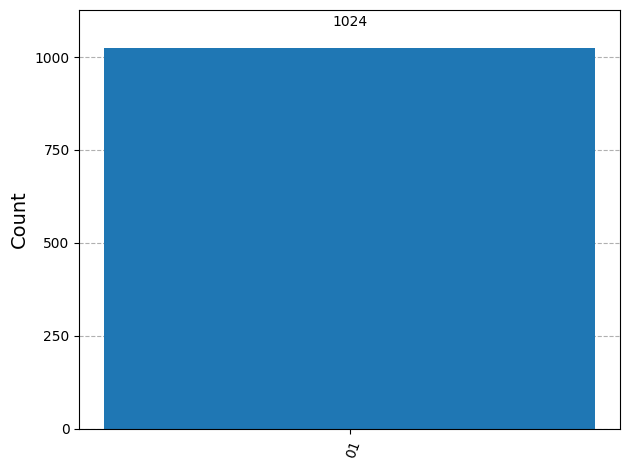

In [61]:
result = AerSimulator().run(protocol).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
    print(f"Measured {outcome} with frequency {frequency}")

display(plot_histogram(statistics))

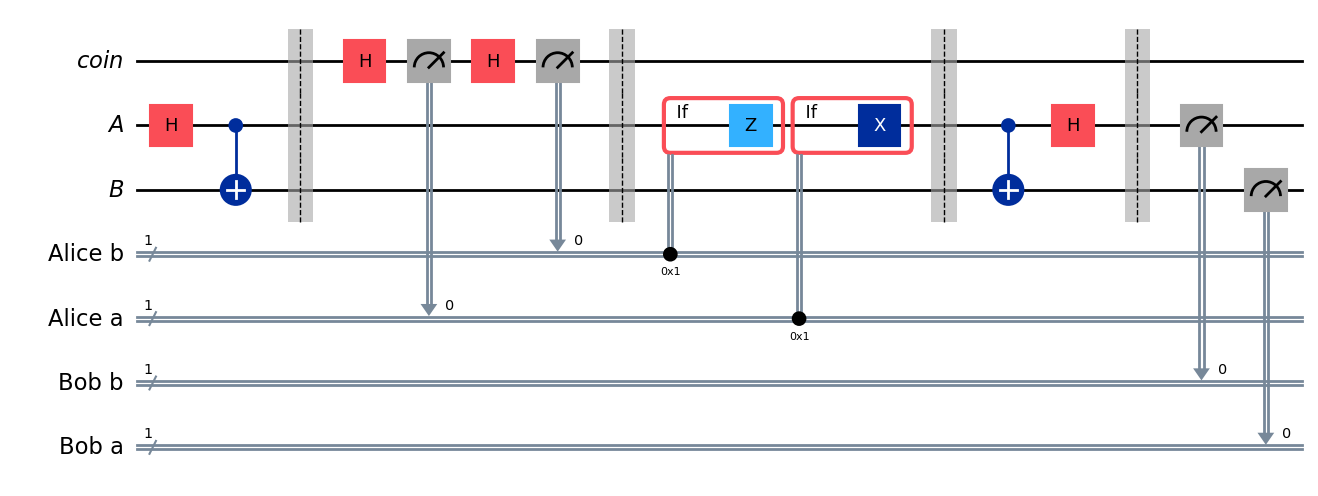

In [65]:
# now we'll show for every possible combo of a and b, we can recover the original message
rbg = QuantumRegister(1, 'coin')

# sender bits
Alice_b = ClassicalRegister(1, "Alice b")
Alice_a = ClassicalRegister(1, "Alice a")

test = QuantumCircuit(rbg, ebit0, ebit1, Alice_b, Alice_a)

# Initialize the ebit
test.h(ebit0)
test.cx(ebit0, ebit1)
test.barrier()

# hadamard on the coin qubit to create a 50/50 superposition between ket1 and ket0
test.h(rbg)
test.measure(rbg, Alice_a)
test.h(rbg)
test.measure(rbg, Alice_b)
test.barrier()

# now run the protocol
with test.if_test((Alice_b, 1), label="Z"):
    test.z(ebit0)
with test.if_test((Alice_a, 1), label="X"):
    test.x(ebit0)
test.barrier()

test.cx(ebit0, ebit1)
test.h(ebit0)
test.barrier()


# now receiver takes over
Bob_b = ClassicalRegister(1, "Bob b")
Bob_a = ClassicalRegister(1, "Bob a")
test.add_register(Bob_b)
test.add_register(Bob_a)
test.measure(ebit0, Bob_b)
test.measure(ebit1, Bob_a)

display(test.draw(output="mpl"))

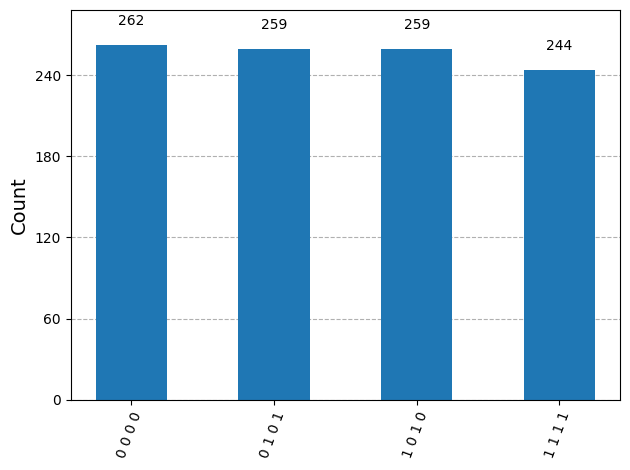

In [ ]:
# run the simulation 
# notice that the first two bits (input) are always the same as the last two bits (output)
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

# CHSH Game

Remember that the game can essentially be defined by the referee, and the referee in the CHSH game is defined by only the below 2 points:
1. The referee chooses x and y uniformly at random from {0, 1}
2. The referee checks if a XOR b == x AND y, if so then the players win, otherwise they lose

In [ ]:
def chsh_game(strategy):
    x, y = random.randint(0, 1), random.randint(0, 1)

    # Use the strategy to determine a and b
    a, b = strategy(x, y)

    # Decide if the strategy wins or loses
    if (a != b) == (x & y):
        return 1  # Win
    return 0 # Lose

(x,y) = (0,0)


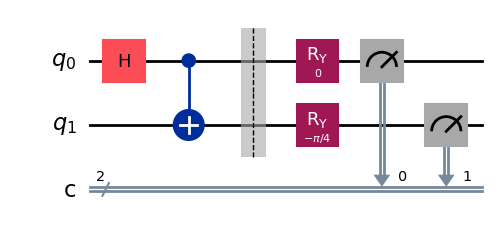

(x,y) = (0,1)


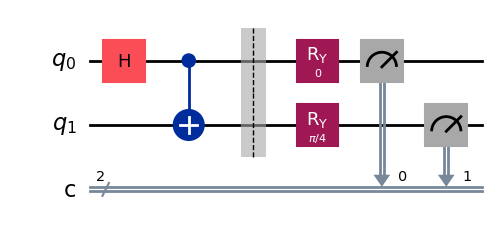

(x,y) = (1,0)


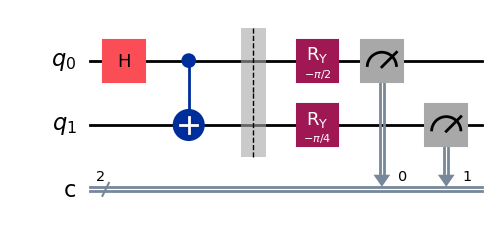

(x,y) = (1,1)


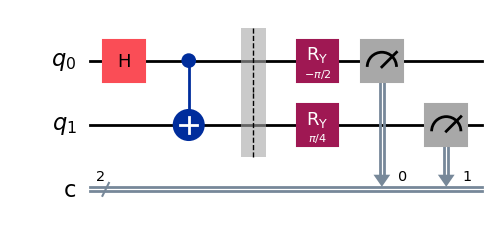

In [69]:
def chsh_circuit(x: int, y: int):
    '''Returns a quantum circuit that implements the CHSH strategy for given inputs x and y.'''
    qc = QuantumCircuit(2, 2)

    # Prepare an e-bit
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()

    # Alice's actions
    if x == 0:
        qc.ry(0, 0)
    else:
        qc.ry(-pi / 2, 0)
    qc.measure(0, 0)

    # Bob's actions
    if y == 0:
        qc.ry(-pi / 4, 1)
    else:
        qc.ry(pi / 4, 1)
    qc.measure(1, 1)

    return qc


# Draw the four possible circuits

print("(x,y) = (0,0)")
display(chsh_circuit(0, 0).draw(output="mpl"))

print("(x,y) = (0,1)")
display(chsh_circuit(0, 1).draw(output="mpl"))

print("(x,y) = (1,0)")
display(chsh_circuit(1, 0).draw(output="mpl"))

print("(x,y) = (1,1)")
display(chsh_circuit(1, 1).draw(output="mpl"))



In [80]:
def quantum_strategy(x, y):
    # Setting `shots=1` to run the circuit once
    result = AerSimulator().run(chsh_circuit(x, y), shots=1).result()
    statistics = result.get_counts()

    # Determine the output bits and return them
    bits = list(statistics.keys())[0]
    a, b = bits[0], bits[1]
    return a, b

NUM_GAMES = 1000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(quantum_strategy)

print("Fraction of games won:", TOTAL_SCORE / NUM_GAMES)

Fraction of games won: 0.857
